In [1]:
import dask
from dask.distributed import Client, wait
from dask import delayed

client = Client(n_workers=7, threads_per_worker=1) 
#client = Client()

client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 7,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43819,Workers: 7
Dashboard: /proxy/8787/status,Total threads: 7
Started: Just now,Total memory: 251.19 GiB
Comm: tcp://127.0.0.1:44513,Total threads: 1
Dashboard: /proxy/44449/status,Memory: 35.88 GiB
Nanny: tcp://127.0.0.1:46873,


In [2]:
#import all the stuff
from netCDF4 import Dataset
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import sys
import cftime
sys.path.append("/g/data/mn51/users/nb6195/project/gwls/")
import gwl
sys.path.append("/g/data/mn51/users/nb6195/project/vpd/VPD")
import VPD_functions as VPD
sys.path.append("/g/data/mn51/users/nb6195/project/dwi/DWI")
import DWI_functions as DWI

In [3]:
def location_coords(location_dict, loc_name):
    lat_ind = round((location_dict[loc_name][0] + 44.5)/0.05)
    lon_ind = round((location_dict[loc_name][1] - 112)/0.05)
    return [lat_ind, lon_ind]

In [156]:
#Set parameters
CMIP='CMIP6'
#AGENCY = 'CSIRO' 
#RCM = 'CCAM-v2203-SN'
AGENCY = 'BOM' 
RCM = 'BARPA-R'

#GCM = 'ACCESS-CM2' #ensemble = 'r4i1p1f1' #Done
#GCM = 'ACCESS-ESM1-5' ensemble = 'r6i1p1f1' #Done
#GCM = 'EC-Earth3' ensemble = 'r1i1p1f1' #Done
#GCM = 'MPI-ESM1-2-HR' ensemble = 'r1i1p1f1' #BOM done, no CSIRO
#GCM = 'CESM2' ensemble = 'r11i1p1f1' #Done
#GCM = 'CMCC-ESM2' ensemble = 'r1i1p1f1' #Done
GCM = 'NorESM2-MM' 
ensemble = 'r1i1p1f1' #Done
#GCM = 'CNRM-ESM2-1' ensemble = 'r1i1p1f2' #CSIRO Done, no BOM

#pathway = 'ssp126'
pathway = 'ssp370'

ddir = f"/g/data/kj66/CORDEX/output-{CMIP}/DD/AUST-05i/{AGENCY}/{GCM}"
bdir = f"/g/data/kj66/CORDEX/output-{CMIP}/bias-adjusted-output/AUST-05i/{AGENCY}/{GCM}"

output_dir = '/g/data/ia39/ncra/bushfire/dwi/'

chosen_gwl = '3.0'

In [160]:
test_index = 'dwi' 

#downscaled data
infiles_d=f"/g/data/ia39/ncra/bushfire/dwi/{GCM}/{pathway}/{ensemble}/{RCM}/v1-r1/day/{pathway}_{GCM}_{RCM}_gwl{chosen_gwl}_{test_index}.nc"
data_d = xr.open_dataset(infiles_d)['__xarray_dataarray_variable__']

#MRNBC data
infiles_m=f"/g/data/ia39/ncra/bushfire/dwi/{GCM}/{pathway}/{ensemble}/{RCM}/v1-r1/day/{pathway}_{GCM}_{RCM}_MRNBC_gwl{chosen_gwl}_{test_index}.nc"
data_m = xr.open_dataset(infiles_m)[test_index]

#QME data
infiles_q=f"/g/data/ia39/ncra/bushfire/dwi/{GCM}/{pathway}/{ensemble}/{RCM}/v1-r1/day/{pathway}_{GCM}_{RCM}_QME_gwl{chosen_gwl}_{test_index}.nc"
data_q = xr.open_dataset(infiles_q)[test_index]

In [161]:
location_dict = {
    'Adelaide' : [-34.95, 138.60],
    'Dandenongs' : [-37.8335, 145.3501],
    'Canberra' : [-35.2802, 149.1310],
    'Manjimup' : [-34.2432, 116.1453],
    'Cradle Mountain' : [-41.6800, 145.9400],
    'Kosciuszko' : [-36.4559, 148.2636],
    'Kuitpo' : [-35.2212, 138.6932],
    'Kinglake' : [-37.53291, 145.33964]
}

In [162]:
loc_name = 'Kinglake'

[lat_ind, lon_ind] = location_coords(location_dict, loc_name)

In [163]:
loc_data_d = data_d.isel(lat = lat_ind, lon = lon_ind)
loc_data_m = data_m.isel(lat = lat_ind, lon = lon_ind)
loc_data_q = data_q.isel(lat = lat_ind, lon = lon_ind)

In [164]:
low_ind = 6562
up_ind = low_ind + 40

In [145]:
low_date_string = loc_data_d.time[low_ind].values.astype(str)[0:10]
up_date_string = loc_data_d.time[up_ind].values.astype(str)[0:10]

IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

For NorESM

In [165]:
low_dt_no_leap = loc_data_d.time[low_ind].values

# Convert to a numeric time value
low_numeric_time = cftime.date2num(low_dt_no_leap, units='days since 2000-01-01')

# Convert back to a standard datetime
low_standard_datetime = cftime.num2date(low_numeric_time, units='days since 2000-01-01')

# Format as a string
low_date_string = low_standard_datetime.strftime('%Y-%m-%d')
#print(low_date_string)  

loc_data_d.time[up_ind]

up_dt_no_leap = loc_data_d.time[up_ind].values

# Convert to a numeric time value
up_numeric_time = cftime.date2num(up_dt_no_leap, units='days since 2000-01-01')

# Convert back to a standard datetime
up_standard_datetime = cftime.num2date(up_numeric_time, units='days since 2000-01-01')

# Format as a string
up_date_string = up_standard_datetime.strftime('%Y-%m-%d')
#print(up_date_string)

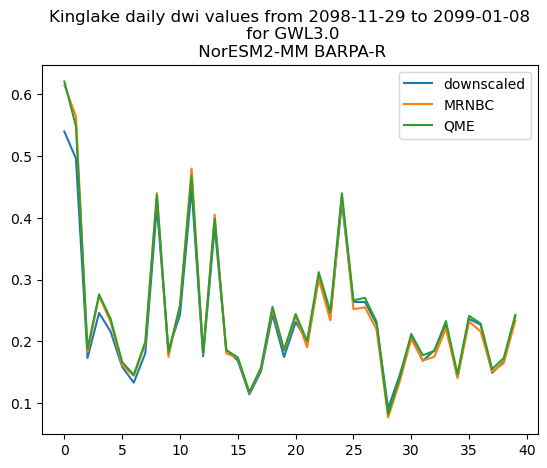

In [166]:
plt.plot(loc_data_d[low_ind:up_ind], label = 'downscaled')
plt.plot(loc_data_m[low_ind:up_ind], label = 'MRNBC')
plt.plot(loc_data_q[low_ind:up_ind], label = 'QME')
plt.title('%s daily %s values from %s to %s\n for GWL%s\n %s %s' %(loc_name, test_index, low_date_string, up_date_string, chosen_gwl, GCM, RCM))
plt.legend()
plt.show()

In [167]:
var1 = 'tasmaxAdjust'
var2 = 'hursminAdjust'
var3 = 'sfcWindmaxAdjust'

d_var1 = 'tasmax'
d_var2 = 'hursmin'
d_var3 = 'sfcWindmax'

In [168]:
#tasmax
m_infiles1a=glob.glob(bdir+f'/historical/{ensemble}/{RCM}/v1-r1-ACS-MRNBC-BARRAR2-1980-2022/day/{var1}/v20241216/{var1}_AUST-05i_{GCM}_historical_{ensemble}_{AGENCY}_{RCM}_v1-r1-ACS-MRNBC-BARRAR2-1980-2022_day_*.nc')
m_infiles1b=glob.glob(bdir+f'/{pathway}/{ensemble}/{RCM}/v1-r1-ACS-MRNBC-BARRAR2-1980-2022/day/{var1}/v20241216/{var1}_AUST-05i_{GCM}_{pathway}_{ensemble}_{AGENCY}_{RCM}_v1-r1-ACS-MRNBC-BARRAR2-1980-2022_day_*.nc')
MRNBC_tasmax_master_ds = xr.open_mfdataset(m_infiles1a + m_infiles1b)

q_infiles1a=glob.glob(bdir+f'/historical/{ensemble}/{RCM}/v1-r1-ACS-QME-BARRAR2-1980-2022/day/{var1}/v20241216/{var1}_AUST-05i_{GCM}_historical_{ensemble}_{AGENCY}_{RCM}_v1-r1-ACS-QME-BARRAR2-1980-2022_day_*.nc')
q_infiles1b=glob.glob(bdir+f'/{pathway}/{ensemble}/{RCM}/v1-r1-ACS-QME-BARRAR2-1980-2022/day/{var1}/v20241216/{var1}_AUST-05i_{GCM}_{pathway}_{ensemble}_{AGENCY}_{RCM}_v1-r1-ACS-QME-BARRAR2-1980-2022_day_*.nc')
QME_tasmax_master_ds = xr.open_mfdataset(q_infiles1a + q_infiles1b)

d_infiles1a=glob.glob(ddir+f'/historical/{ensemble}/{RCM}/v1-r1/day/{d_var1}/v20241216/{d_var1}_AUST-05i_{GCM}_historical_{ensemble}_{AGENCY}_{RCM}_v1-r1_day_*.nc')
d_infiles1b=glob.glob(ddir+f'/{pathway}/{ensemble}/{RCM}/v1-r1/day/{d_var1}/v20241216/{d_var1}_AUST-05i_{GCM}_{pathway}_{ensemble}_{AGENCY}_{RCM}_v1-r1_day_*.nc')
D_tasmax_master_ds = xr.open_mfdataset(d_infiles1a + d_infiles1b)

In [169]:
#hursmin
m_infiles2a=glob.glob(bdir+f'/historical/{ensemble}/{RCM}/v1-r1-ACS-MRNBC-BARRAR2-1980-2022/day/{var2}/v20241216/{var2}_AUST-05i_{GCM}_historical_{ensemble}_{AGENCY}_{RCM}_v1-r1-ACS-MRNBC-BARRAR2-1980-2022_day_*.nc')
m_infiles2b=glob.glob(bdir+f'/{pathway}/{ensemble}/{RCM}/v1-r1-ACS-MRNBC-BARRAR2-1980-2022/day/{var2}/v20241216/{var2}_AUST-05i_{GCM}_{pathway}_{ensemble}_{AGENCY}_{RCM}_v1-r1-ACS-MRNBC-BARRAR2-1980-2022_day_*.nc')
MRNBC_hursmin_master_ds = xr.open_mfdataset(m_infiles2a + m_infiles2b)

q_infiles2a=glob.glob(bdir+f'/historical/{ensemble}/{RCM}/v1-r1-ACS-QME-BARRAR2-1980-2022/day/{var2}/v20241216/{var2}_AUST-05i_{GCM}_historical_{ensemble}_{AGENCY}_{RCM}_v1-r1-ACS-QME-BARRAR2-1980-2022_day_*.nc')
q_infiles2b=glob.glob(bdir+f'/{pathway}/{ensemble}/{RCM}/v1-r1-ACS-QME-BARRAR2-1980-2022/day/{var2}/v20241216/{var2}_AUST-05i_{GCM}_{pathway}_{ensemble}_{AGENCY}_{RCM}_v1-r1-ACS-QME-BARRAR2-1980-2022_day_*.nc')
QME_hursmin_master_ds = xr.open_mfdataset(q_infiles2a + q_infiles2b)

d_infiles2a=glob.glob(ddir+f'/historical/{ensemble}/{RCM}/v1-r1/day/{d_var2}/v20241216/{d_var2}_AUST-05i_{GCM}_historical_{ensemble}_{AGENCY}_{RCM}_v1-r1_day_*.nc')
d_infiles2b=glob.glob(ddir+f'/{pathway}/{ensemble}/{RCM}/v1-r1/day/{d_var2}/v20241216/{d_var2}_AUST-05i_{GCM}_{pathway}_{ensemble}_{AGENCY}_{RCM}_v1-r1_day_*.nc')
D_hursmin_master_ds = xr.open_mfdataset(d_infiles2a + d_infiles2b)

In [170]:
#wind
m_infiles3a=glob.glob(bdir+f'/historical/{ensemble}/{RCM}/v1-r1-ACS-MRNBC-BARRAR2-1980-2022/day/{var3}/v20241216/{var3}_AUST-05i_{GCM}_historical_{ensemble}_{AGENCY}_{RCM}_v1-r1-ACS-MRNBC-BARRAR2-1980-2022_day_*.nc')
m_infiles3b=glob.glob(bdir+f'/{pathway}/{ensemble}/{RCM}/v1-r1-ACS-MRNBC-BARRAR2-1980-2022/day/{var3}/v20241216/{var3}_AUST-05i_{GCM}_{pathway}_{ensemble}_{AGENCY}_{RCM}_v1-r1-ACS-MRNBC-BARRAR2-1980-2022_day_*.nc')
MRNBC_wind_sp_master_ds = xr.open_mfdataset(m_infiles3a + m_infiles3b)

q_infiles3a=glob.glob(bdir+f'/historical/{ensemble}/{RCM}/v1-r1-ACS-QME-BARRAR2-1980-2022/day/{var3}/v20241216/{var3}_AUST-05i_{GCM}_historical_{ensemble}_{AGENCY}_{RCM}_v1-r1-ACS-QME-BARRAR2-1980-2022_day_*.nc')
q_infiles3b=glob.glob(bdir+f'/{pathway}/{ensemble}/{RCM}/v1-r1-ACS-QME-BARRAR2-1980-2022/day/{var3}/v20241216/{var3}_AUST-05i_{GCM}_{pathway}_{ensemble}_{AGENCY}_{RCM}_v1-r1-ACS-QME-BARRAR2-1980-2022_day_*.nc')
QME_wind_sp_master_ds = xr.open_mfdataset(q_infiles3a + q_infiles3b)

d_infiles3a=glob.glob(ddir+f'/historical/{ensemble}/{RCM}/v1-r1/day/{d_var3}/v20241216/{d_var3}_AUST-05i_{GCM}_historical_{ensemble}_{AGENCY}_{RCM}_v1-r1_day_*.nc')
d_infiles3b=glob.glob(ddir+f'/{pathway}/{ensemble}/{RCM}/v1-r1/day/{d_var3}/v20241216/{d_var3}_AUST-05i_{GCM}_{pathway}_{ensemble}_{AGENCY}_{RCM}_v1-r1_day_*.nc')
D_wind_sp_master_ds = xr.open_mfdataset(d_infiles3a + d_infiles3b)

In [171]:
MRNBC_gwl_tasmax = gwl.get_GWL_timeslice(MRNBC_tasmax_master_ds,CMIP,GCM,ensemble,pathway,GWL=chosen_gwl)[var1]
MRNBC_gwl_rh = gwl.get_GWL_timeslice(MRNBC_hursmin_master_ds,CMIP,GCM,ensemble,pathway,GWL=chosen_gwl)[var2]
MRNBC_gwl_wind_sp = gwl.get_GWL_timeslice(MRNBC_wind_sp_master_ds,CMIP,GCM,ensemble,pathway,GWL=chosen_gwl)[var3]

QME_gwl_tasmax = gwl.get_GWL_timeslice(QME_tasmax_master_ds,CMIP,GCM,ensemble,pathway,GWL=chosen_gwl)[var1]
QME_gwl_rh = gwl.get_GWL_timeslice(QME_hursmin_master_ds,CMIP,GCM,ensemble,pathway,GWL=chosen_gwl)[var2]
QME_gwl_wind_sp = gwl.get_GWL_timeslice(QME_wind_sp_master_ds,CMIP,GCM,ensemble,pathway,GWL=chosen_gwl)[var3]

D_gwl_tasmax = gwl.get_GWL_timeslice(D_tasmax_master_ds,CMIP,GCM,ensemble,pathway,GWL=chosen_gwl)[d_var1]
D_gwl_rh = gwl.get_GWL_timeslice(D_hursmin_master_ds,CMIP,GCM,ensemble,pathway,GWL=chosen_gwl)[d_var2]
D_gwl_wind_sp = gwl.get_GWL_timeslice(D_wind_sp_master_ds,CMIP,GCM,ensemble,pathway,GWL=chosen_gwl)[d_var3]

In [172]:
loc_MRNBC_gwl_tasmax = MRNBC_gwl_tasmax.isel(lat = lat_ind, lon = lon_ind)
loc_MRNBC_gwl_rh = MRNBC_gwl_rh.isel(lat = lat_ind, lon = lon_ind)
loc_MRNBC_gwl_wind_sp = MRNBC_gwl_wind_sp.isel(lat = lat_ind, lon = lon_ind)

loc_QME_gwl_tasmax = QME_gwl_tasmax.isel(lat = lat_ind, lon = lon_ind)
loc_QME_gwl_rh = QME_gwl_rh.isel(lat = lat_ind, lon = lon_ind)
loc_QME_gwl_wind_sp = QME_gwl_wind_sp.isel(lat = lat_ind, lon = lon_ind)

loc_D_gwl_tasmax = D_gwl_tasmax.isel(lat = lat_ind, lon = lon_ind)
loc_D_gwl_rh = D_gwl_rh.isel(lat = lat_ind, lon = lon_ind)
loc_D_gwl_wind_sp = D_gwl_wind_sp.isel(lat = lat_ind, lon = lon_ind)

In [173]:
gwl_vpd_MRNBC, monthly_mean_vpd_MRNBC = VPD.vpd_calc(loc_MRNBC_gwl_rh, loc_MRNBC_gwl_tasmax, chosen_gwl)
gwl_vpd_QME, monthly_mean_vpd_QME = VPD.vpd_calc(loc_QME_gwl_rh, loc_QME_gwl_tasmax, chosen_gwl)
gwl_vpd_D, monthly_mean_vpd_D = VPD.vpd_calc(loc_D_gwl_rh, loc_D_gwl_tasmax, chosen_gwl)

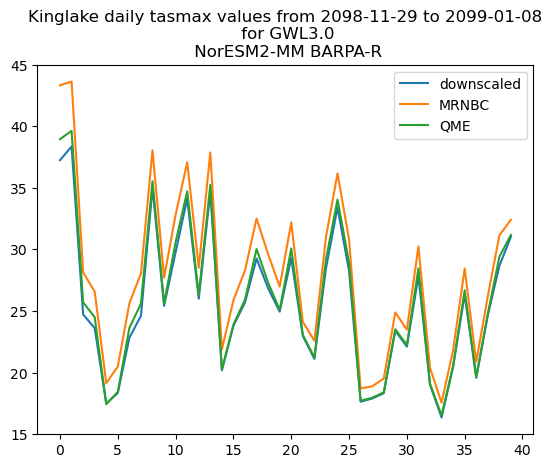

In [174]:
plt.plot(loc_D_gwl_tasmax[low_ind:up_ind], label = 'downscaled')
plt.plot(loc_MRNBC_gwl_tasmax[low_ind:up_ind], label = 'MRNBC')
plt.plot(loc_QME_gwl_tasmax[low_ind:up_ind], label = 'QME')
plt.title('%s daily %s values from %s to %s\n for GWL%s\n %s %s' %(loc_name, d_var1, low_date_string, up_date_string, chosen_gwl, GCM, RCM))
plt.legend()
plt.show()

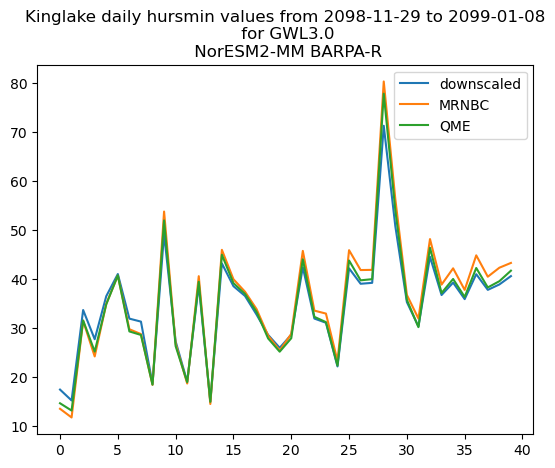

In [175]:
plt.plot(loc_D_gwl_rh[low_ind:up_ind], label = 'downscaled')
plt.plot(loc_MRNBC_gwl_rh[low_ind:up_ind], label = 'MRNBC')
plt.plot(loc_QME_gwl_rh[low_ind:up_ind], label = 'QME')
plt.title('%s daily %s values from %s to %s\n for GWL%s\n %s %s' %(loc_name, d_var2, low_date_string, up_date_string, chosen_gwl, GCM, RCM))
plt.legend()
plt.show()

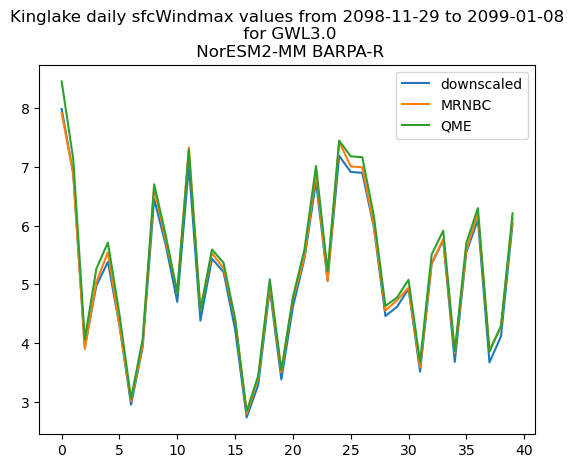

In [176]:
plt.plot(loc_D_gwl_wind_sp[low_ind:up_ind], label = 'downscaled')
plt.plot(loc_MRNBC_gwl_wind_sp[low_ind:up_ind], label = 'MRNBC')
plt.plot(loc_QME_gwl_wind_sp[low_ind:up_ind], label = 'QME')
plt.title('%s daily %s values from %s to %s\n for GWL%s\n %s %s' %(loc_name, d_var3, low_date_string, up_date_string, chosen_gwl, GCM, RCM))
plt.legend()
plt.show()

In [177]:
#monthly_mean_vpd_D['monthly_mean_vpd']

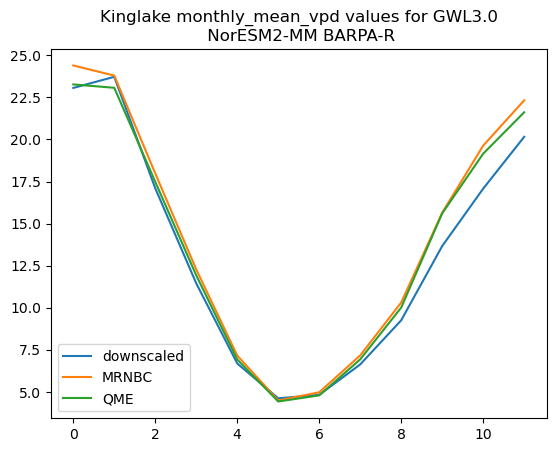

In [178]:
plt.plot(monthly_mean_vpd_D['monthly_mean_vpd'], label = 'downscaled')
plt.plot(monthly_mean_vpd_MRNBC['monthly_mean_vpd'], label = 'MRNBC')
plt.plot(monthly_mean_vpd_QME['monthly_mean_vpd'], label = 'QME')
plt.title('%s monthly_mean_vpd values for GWL%s\n %s %s' %(loc_name, chosen_gwl, GCM, RCM))
plt.legend()
plt.show()

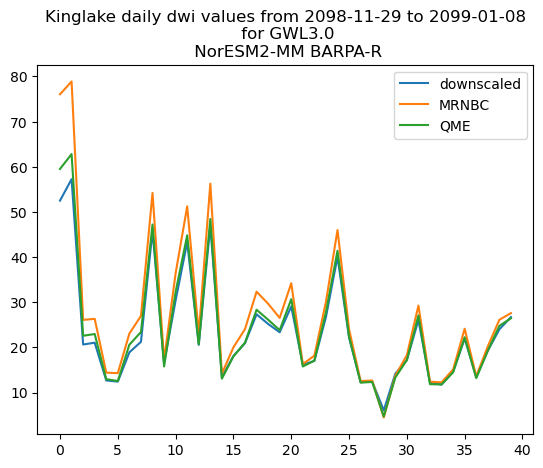

In [179]:
plt.plot(gwl_vpd_D['vpd'][low_ind:up_ind], label = 'downscaled')
plt.plot(gwl_vpd_MRNBC['vpd'][low_ind:up_ind], label = 'MRNBC')
plt.plot(gwl_vpd_QME['vpd'][low_ind:up_ind], label = 'QME')
plt.title('%s daily %s values from %s to %s\n for GWL%s\n %s %s' %(loc_name, test_index, low_date_string, up_date_string, chosen_gwl, GCM, RCM))
plt.legend()
plt.show()

In [180]:
#Vesta DWI: fire spread rate, expect up to 10% of wind speed in 
#extreme conditions (very dry M. Cruz results).
#Values here from the paper provide an excellent approximation for 
#windspeeds between 10 and 80 km\ h^{-1}, using the longest unburned 
#fuel settings (10+ years) provided in Table 6 of Cheney et al. (2012).  
A = 5
B = 20
C = 0
D = 25

In [181]:
gwl_dwi_D = DWI.calc_dwi(loc_QME_gwl_tasmax, loc_QME_gwl_rh, loc_QME_gwl_wind_sp, chosen_gwl, A, B, C, D)['dwi']
gwl_dwi_MRNBC = DWI.calc_dwi(loc_MRNBC_gwl_tasmax, loc_MRNBC_gwl_rh, loc_MRNBC_gwl_wind_sp, chosen_gwl, A, B, C, D)['dwi']
gwl_dwi_QME = DWI.calc_dwi(loc_D_gwl_tasmax, loc_D_gwl_rh, loc_D_gwl_wind_sp, chosen_gwl, A, B, C, D)['dwi']

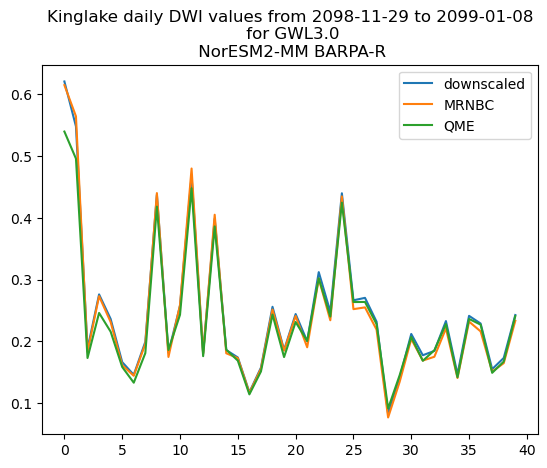

In [182]:
plt.plot(gwl_dwi_D[low_ind:up_ind], label = 'downscaled')
plt.plot(gwl_dwi_MRNBC[low_ind:up_ind], label = 'MRNBC')
plt.plot(gwl_dwi_QME[low_ind:up_ind], label = 'QME')
plt.title('%s daily DWI values from %s to %s\n for GWL%s\n %s %s' %(loc_name, low_date_string, up_date_string, chosen_gwl, GCM, RCM))
plt.legend()
plt.show()

In [183]:
gwl_faux_ffdi_D = DWI.calc_faux_ffdi(gwl_dwi_D, loc_D_gwl_tasmax, chosen_gwl)
gwl_faux_ffdi_MRNBC = DWI.calc_faux_ffdi(gwl_dwi_MRNBC, loc_MRNBC_gwl_tasmax, chosen_gwl)
gwl_faux_ffdi_QME = DWI.calc_faux_ffdi(gwl_dwi_QME, loc_QME_gwl_tasmax, chosen_gwl)

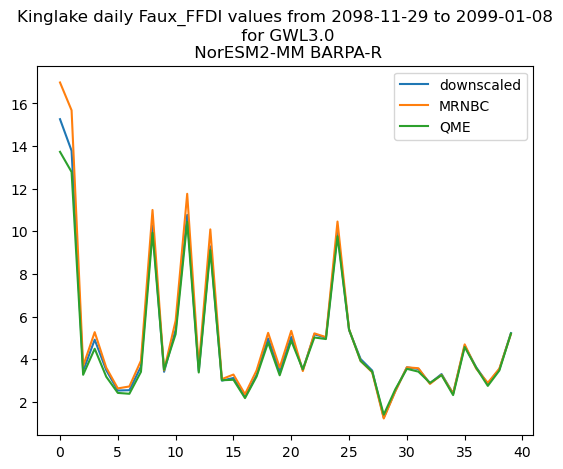

In [184]:
plt.plot(gwl_faux_ffdi_D['faux_ffdi'][low_ind:up_ind], label = 'downscaled')
plt.plot(gwl_faux_ffdi_MRNBC['faux_ffdi'][low_ind:up_ind], label = 'MRNBC')
plt.plot(gwl_faux_ffdi_QME['faux_ffdi'][low_ind:up_ind], label = 'QME')
plt.title('%s daily Faux_FFDI values from %s to %s\n for GWL%s\n %s %s' %(loc_name, low_date_string, up_date_string, chosen_gwl, GCM, RCM))
plt.legend()
plt.show()

In [185]:
dpd_d = DWI.calc_dpd(loc_D_gwl_tasmax, loc_D_gwl_rh, chosen_gwl)
dpd_m = DWI.calc_dpd(loc_MRNBC_gwl_tasmax, loc_MRNBC_gwl_rh, chosen_gwl)
dpd_q = DWI.calc_dpd(loc_QME_gwl_tasmax, loc_QME_gwl_rh, chosen_gwl)

In [186]:
#dpd_d['dpd']

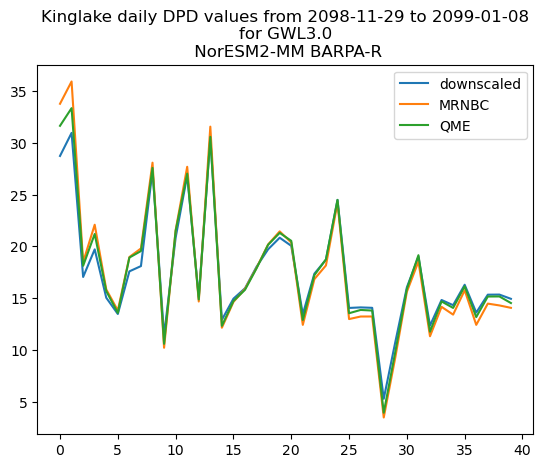

In [187]:
plt.plot(dpd_d['dpd'][low_ind:up_ind], label = 'downscaled')
plt.plot(dpd_m['dpd'][low_ind:up_ind], label = 'MRNBC')
plt.plot(dpd_q['dpd'][low_ind:up_ind], label = 'QME')
plt.title('%s daily DPD values from %s to %s\nfor GWL%s\n %s %s' %(loc_name, low_date_string, up_date_string, chosen_gwl, GCM, RCM))
plt.legend()
plt.show()

In [188]:
def calc_Td(ds_temp, ds_rh, chosen_gwl):
    gamma = np.log(ds_rh/100) + 17.67*ds_temp/(243.5 + ds_temp)
    Td = 243.5 * gamma/(17.67 - gamma)
    Td.attrs = {
        'standard_name': 'Td',
        'units': 'degC',
    }
    ds_dpd = xr.Dataset({'Td' : Td})
    ds_rh.close()
    ds_temp.close()
    return Td

In [189]:
Td_d = calc_Td(loc_D_gwl_tasmax, loc_D_gwl_rh, chosen_gwl)
Td_m = calc_Td(loc_MRNBC_gwl_tasmax, loc_MRNBC_gwl_rh, chosen_gwl)
Td_q = calc_Td(loc_QME_gwl_tasmax, loc_QME_gwl_rh, chosen_gwl)

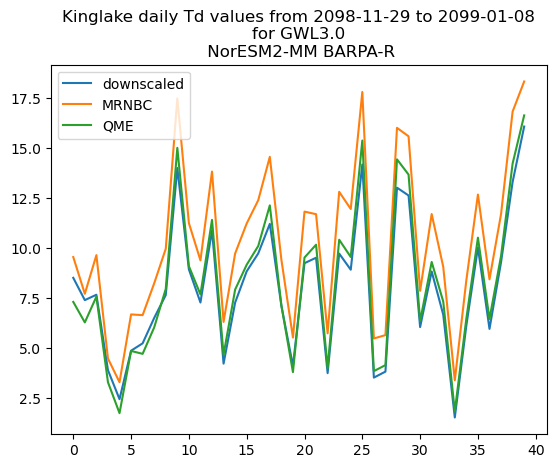

In [190]:
plt.plot(Td_d[low_ind:up_ind], label = 'downscaled')
plt.plot(Td_m[low_ind:up_ind], label = 'MRNBC')
plt.plot(Td_q[low_ind:up_ind], label = 'QME')
plt.title('%s daily Td values from %s to %s\nfor GWL%s\n %s %s' %(loc_name, low_date_string, up_date_string, chosen_gwl, GCM, RCM))
plt.legend()
plt.show()

In [191]:
def color_ext_red(val):
    """
    Takes a scalar and returns a string with
    the css property `'color: red'` for negative
    strings, black otherwise.
    """
    color = 'red' if val < 5 else 'black'
    return 'color: % s' % color

# creating a DataFrame
dict = {#'T downscaled' : loc_D_gwl_tasmax[low_ind:up_ind].to_pandas(),
        #'RH downscaled' : loc_D_gwl_rh[low_ind:up_ind].to_pandas(),
        #'Td downscaled' : Td_d[low_ind:up_ind].to_pandas(),
        'T MRNBC' : loc_MRNBC_gwl_tasmax[low_ind:up_ind].to_pandas(),
        'RH MRNBC' : loc_MRNBC_gwl_rh[low_ind:up_ind].to_pandas(),
        'Td MRNBC' : Td_m[low_ind:up_ind].to_pandas(),
        'T QME' : loc_QME_gwl_tasmax[low_ind:up_ind].to_pandas(),
        'RH QME' : loc_QME_gwl_rh[low_ind:up_ind].to_pandas(),
        'Td QME' : Td_q[low_ind:up_ind].to_pandas(),}
df = pd.DataFrame(dict)

# displaying the DataFrame
df.style.applymap(color_ext_red)

/jobfs/149105411.gadi-pbs/ipykernel_1761971/189848986.py:23: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df.style.applymap(color_ext_red)


,T MRNBC,RH MRNBC,Td MRNBC,T QME,RH QME,Td QME
time,,,,,,
2098-12-24 12:00:00,43.328125,13.500000,9.548263,38.953125,14.625000,7.301675
2098-12-25 12:00:00,43.640625,11.726562,7.708768,39.632812,13.140625,6.275885
2098-12-26 12:00:00,28.140625,31.429688,9.643035,25.703125,31.515625,7.564901
2098-12-27 12:00:00,26.570312,24.171875,4.468861,24.492188,25.164062,3.283931
2098-12-28 12:00:00,19.140625,34.898438,3.282323,17.429688,34.804688,1.733563
2098-12-29 12:00:00,20.500000,40.632812,6.675714,18.437500,40.703125,4.847585
2098-12-30 12:00:00,25.625000,29.718750,6.640318,23.632812,29.273438,4.702031
2098-12-31 12:00:00,28.046875,28.734375,8.234143,25.585938,28.554688,6.027009
2099-01-01 12:00:00,38.054688,18.382812,9.962165,35.539062,18.421875,7.952866
